In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy 
from pfapack import pfaffian as pf


We assume the form 

$$X = e^{\frac{1}{4}\gamma^T A \gamma}$$

which is characterized by 

$$\eta, B$$

In [ ]:
def get_eta_B(A):

    B = scipy.linalg.expm(-A)

    sinhA = scipy.linalg.sinhm(A/4)

    bdim = B.shape[0]

    M = np.zeros((2*bdim, 2*bdim), dtype = np.complex128)

    M[0:bdim, 0:bdim] = np.sqrt(2) * sinhA
    M[bdim:,0:bdim]   = np.identity(bdim)
    M[0:bdim,bdim:]   = -np.identity(bdim)
    M[bdim:,bdim:]    = np.sqrt(2) * sinhA

    eta = np.power(-1,bdim//2) * pf.pfaffian(M)

    return eta, B

def multiplication(eta1, B1, eta2, B2):

    bdim = B1.shape[0]

    M = np.zeros((2*bdim, 2*bdim), dtype = np.complex128)

    G1 = (np.identity(bdim) - B1) @ scipy.linalg.inv(np.identity(bdim) + B1)
    G2 = (np.identity(bdim) - B2) @ scipy.linalg.inv(np.identity(bdim) + B2)

    M[0:bdim, 0:bdim] = G1
    M[bdim:,0:bdim]   = np.identity(bdim)
    M[0:bdim,bdim:]   = -np.identity(bdim)
    M[bdim:,bdim:]    = G2

    eta12 = np.power(-1,bdim//2) * eta1 * eta2 * pf.pfaffian(M)

    B12   = B1@B2

    return eta12, B12

def recursive_eta(Alist):

    Ntau = len(Alist)
    N    = Alist[0].shape[0]//2

    eta, B = get_eta_B(Alist[0])

    eta_prod = eta
    B_prod = B

    for i in range(Ntau-1):

        next_eta, next_B = get_eta_B(Alist[i+1])

        eta_prod, B_prod = multiplication(eta_prod, B_prod, next_eta, next_B)

    return eta_prod*np.power(2, N)

def brute_force_trace(Alist):

    Ntau = len(Alist)
    N    = Alist[0].shape[0] // 2


    eta_prod = 1
    etas = np.zeros(Ntau, dtype=np.complex128)
    Bs   = np.zeros((2*N, 2*N, Ntau), dtype=np.complex128)
    Gs   = np.zeros((2*N, 2*N, Ntau), dtype=np.complex128)

    M    = np.zeros((2*N*Ntau, 2*N*Ntau), dtype=np.complex128)

    I = np.eye(2*N, dtype=np.complex128)

    # Fill M in 2N x 2N blocks
    for i in range(Ntau):
        for j in range(i + 1, Ntau):
            # checkerboard on the upper-right triangle, starting with "-"
            sgn = -1 if ((i + j) % 2 == 1) else 1

            r_i = slice(2*N*i, 2*N*(i + 1))
            r_j = slice(2*N*j, 2*N*(j + 1))

            M[r_i, r_j] = sgn * I          # upper-right block
            M[r_j, r_i] = -sgn * I         # lower-left block (antisymmetric)


    for i in range(Ntau):
        etas[i], Bs[:, :, i] = get_eta_B(Alist[i])
        Gs[:, :, i]          = scipy.linalg.tanhm(Alist[i] / 2)
        eta_prod *= etas[i]
        M[i*2*N:(i+1)*2*N,i*2*N:(i+1)*2*N] = Gs[:,:,i]

    W = np.power(-1, N*Ntau//2) * np.power(2, N) * eta_prod * pf.pfaffian(M)

    return W

def catterpillar(Alist):

    Ntau = len(Alist)
    N    = Alist[0].shape[0] // 2

    temp = np.zeros((4*N, 4*N), dtype = np.complex128)

    Bs = np.zeros((2*N, 2*N, Ntau), dtype = np.complex128)
    etas = np.zeros(Ntau, dtype = np.complex128)
    eta_prod = 1
    pf_prod  = 1

    current_Bstring = np.identity(2*N, dtype=np.complex128)

    for i in range(Ntau):

        etas[i], Bs[:,:,i] = get_eta_B(Alist[i])
        eta_prod *= etas[i]

    for i in range(Ntau - 1):

        current_Bstring = current_Bstring @ Bs[:,:,i]

        temp[:2*N,:2*N] = (np.identity(2*N) - current_Bstring) @ scipy.linalg.inv(np.identity(2*N) + current_Bstring)
        temp[:2*N,2*N:] = -np.identity(2*N)
        temp[2*N:,:2*N] = np.identity(2*N)
        temp[2*N:,2*N:] = scipy.linalg.tanhm(0.5*Alist[i+1])

        pf_prod *= pf.pfaffian(temp)

    W = np.power(2, N) * np.power(-1, (Ntau + 1)*N) *eta_prod * pf_prod

    return W

def generate_random_Alist(N, Ntau, scaling = 0.1):

    Alist = []
    rng = np.random.default_rng(seed = 412425)

    for i in range(Ntau):

        A = rng.normal(loc = 0, scale = scaling, size = (2*N, 2*N)) + 1j * rng.normal(loc = 0, scale = scaling, size = (2*N, 2*N))
        A = 0.5*(A - A.T)
        Alist.append(A)

    return Alist

def get_J_cross(matrix):

    dim = matrix.shape[0]

    Jcross = np.zeros((2*dim, 2*dim), dtype = matrix.dtype)

    Jcross[:dim, dim:2*dim] = - matrix
    Jcross[dim:2*dim, :dim] = + matrix

    return Jcross

def cos_string(phi,dtau):

    prod = 1

    for i in range(phi.size):

        prod = prod * np.cos(phi[i]*dtau) * (-1)

    return prod


class HMC():

    def __init__(self, t_MD, N_MD, model, saver, seed = 1337):
        self.N_MD = N_MD
        self.t_MD  = t_MD
        self.dt, self.dt_half = t_MD/self.N_MD, 0.5*t_MD/self.N_MD
        self.model = model
        self.cfg_shape = model.shape
        self.saver = saver
        self.steps = self.acc = 0
        self.rng   = np.random.default_rng(seed)


    def step(self):

        self.mom = self.rng.normal(loc = 0.0, scale = 1.0, size = self.cfg_shape).astype(np.float64)

        new_cfg  = np.copy(self.model.cfg)

        old_H = self.model.action + 0.5 * np.sum(np.power(self.mom, 2))

        self.mom -= self.dt_half*self.model.get_action_gradient(new_cfg)

        for _ in range(self.N_MD-1):

            new_cfg +=self.dt*self.mom
            self.mom -= self.dt*self.model.get_action_gradient(new_cfg)
        
        new_cfg += self.dt*self.mom
        self.mom -= self.dt_half*self.model.get_action_gradient(new_cfg)

        new_action = self.model.get_action(new_cfg)

        new_H = new_action + 0.5* np.sum(np.power(self.mom, 2))


        dH    = new_H - old_H
        p = np.exp(-dH)
        r = self.rng.random()
        
        if r < p :

            self.acc += 1

            self.model.cfg = new_cfg
            self.model.action = new_action

        self.steps += 1


    def save(self):
        self.model.update_obs()
        self.saver.save_cfg_and_obs(self.model.cfg, self.model.obs_dict)

    def output_acc(self):
        return self.acc/self.steps
        
    def reset_acc(self):
        self.acc = self.steps = 0

    def output_model(self):
        return self.model

    def close_file(self):
        self.saver.close()



class Kitaev_action():
    def __init__(self, L, U, Delta, mu, dtau, Ntau, seed = 153525):
        #set paramters and initialize configuration     
        self.U = U
        self.mu = mu
        self.dtau = dtau
        self.Ntau = Ntau
        self.Delta = Delta
        self.L = L
        self.Dplus = 1 + Delta
        self.Dminus = 1 - Delta

        self.rng = np.random.default_rng(seed)
        self.shape = (L, Ntau)
        self.cfg = self.rng.normal(loc=0.0, scale = 1/np.sqrt(np.prod(self.shape)), size = self.shape).astype(np.float64)
        self.gradient = None
        self.J = np.array([[0,-1],[1,0]])
        self.I = np.eye(2)

        self.A_odd = np.zeros((2*L, 2*L), dtype = np.complex128)
        self.A_odd[:L,:L] = np.roll(np.eye(L)*self.Dminus, 1, axis = 1) - np.roll(np.eye(L)*self.Dminus, -1, axis = 1)
        self.A_odd[L:,L:] = np.roll(np.eye(L)*self.Dplus, 1, axis = 1) - np.roll(np.eye(L)*self.Dplus, -1, axis = 1)

        self.A_odd[:L,L:] = -np.eye(L)*mu
        self.A_odd[L:,:L] = np.eye(L)*mu

        self.A_odd[L-1, 0] = 0
        self.A_odd[0, L-1] = 0

        self.A_odd[2*L - 1, L] = 0
        self.A_odd[L, 2*L-1]   = 0

        self.A_odd = self.A_odd * self.dtau * 1j
        self.eta_odd, self.B_odd = get_eta_B(self.A_odd)
        self.G_odd = scipy.linalg.tanhm(self.A_odd/2)

        self.eta_odd_prod = np.power(self.eta_odd, self.Ntau)

        print(self.cfg.shape)


        self.action = None

    def get_action_catterpiller(self, cfg):
        
        B_prod = np.eye(2*self.L)
        G_prod = np.eye(2*self.L)

        Gs_even = np.zeros((2*self.L, 2*self.L, self.Ntau))

        temp = np.zeros((4*self.L, 4*self.L))

        eta_prod = np.prod(np.cos(2*self.dtau*cfg))*self.eta_odd_prod

        for i in range(self.Ntau):

            Gs_even[:,:,i] = np.kron(self.J, np.diag(np.tan(self.dtau * cfg[:,i])))
        
            



(4, 8)


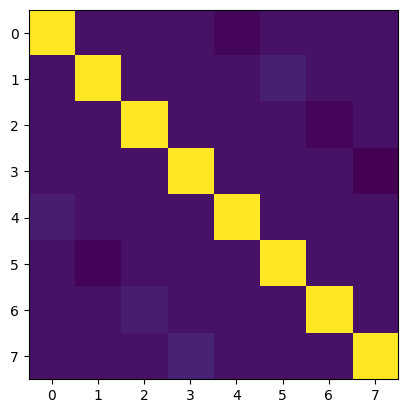

In [13]:
L = 4
U = 1
Delta = 0.2
mu = 2
dtau = 0.1
Ntau = 8

model = Kitaev_action(L, U, Delta, mu, dtau, Ntau)
model.get_action_catterpiller(model.cfg)


In [18]:
N = 4
dtau = 0.2
rng = np.random.default_rng(4135)
phi = rng.normal(loc = 0.0, scale = 1, size = (N))
temp = np.diag(2*dtau*phi)

A = get_J_cross(temp)

eta, B = get_eta_B(A)
eta_fast = cos_string(phi, dtau)

print(eta)
print(eta_fast)


(0.9658843218947372+0j)
0.9658843218947372


In [ ]:
catterpillar(Alist)

In [ ]:
brute_force_trace(Alist)

In [ ]:
recursive_eta(Alist)